In [18]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) #low-pass filter
HPF = np.array([-1/np.sqrt(2), (1/np.sqrt(2))]) #high-pass filter

In [20]:
def filter_horizontal(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

def filter_horizontal(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2

    padd = np.pad(
        image,
        ((0,0),(pad_width,pad_width)),
        mode='constant'
    )

    conv = np.zeros(image.shape)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i,j] += (
                    padd[i,j+x]
                    * kernel[ukuran_kernel-1-x]
                )

    return conv

def filter_vertikal(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

def subsampel_kolom(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def subsampel_baris(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi_citra(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255



In [21]:
def ekspansi_baris(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def ekspansi_kolom(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)): 
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def bangun_ulang_citra(LL, LH, HL, HH, LPF, HPF):
    upsampling = ekspansi_baris(LL)
    konvolusiL = filter_vertikal(upsampling, LPF)

    upsampling = ekspansi_baris(LH)
    konvolusiH = filter_vertikal(upsampling, HPF)

    upsampling = ekspansi_kolom(konvolusiL + konvolusiH)
    konvolusiL2 = filter_horizontal(upsampling, LPF)

    upsampling = ekspansi_baris(HL)
    konvolusiL = filter_vertikal(upsampling, LPF)

    upsampling = ekspansi_baris(HH)
    konvolusiH = filter_vertikal(upsampling, HPF)

    upsampling = ekspansi_kolom(konvolusiL + konvolusiH)
    konvolusiH2 = filter_horizontal(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [22]:
def hitung_matriks_kookurensi(image, distances, angles, levels=256, symmetric=True, normed=True):
    angle = angles[0]

    if angle == 0:
        dr, dc = 0, 1
    elif angle == np.pi / 4:
        dr, dc = -1, 1
    elif angle == np.pi / 2:
        dr, dc = -1, 0
    elif angle == 3 * np.pi / 4:
        dr, dc = -1, -1

    glcm_matrix = np.zeros((levels, levels))
    h, w = image.shape

    for i in range(h):
        for j in range(w):
            row_tetangga = i + dr
            col_tetangga = j + dc

            if 0 <= row_tetangga < h and 0 <= col_tetangga < w:
                ref_pixel = int(image[i][j])
                neighbor_pixel = int(image[row_tetangga][col_tetangga])
                glcm_matrix[ref_pixel][neighbor_pixel] += 1

    if symmetric:
        glcm_matrix = glcm_matrix + glcm_matrix.T

    if normed:
        total = np.sum(glcm_matrix)
        if total > 0:
            glcm_matrix = glcm_matrix / total

    return np.reshape(glcm_matrix, (levels, levels, 1, 1))


def ekstrak_fitur_kookurensi(matriks, prop):
    buat_glcm = matriks[:, :, 0, 0]
    levels = buat_glcm.shape[0]

    i_indices, j_indices = np.ogrid[:levels, :levels]

    if prop == 'hitung_kontras':
        weights = (i_indices - j_indices) ** 2
        hasil = np.sum(buat_glcm * weights)

    elif prop == 'hitung_ketidakmiripan':
        weights = np.abs(i_indices - j_indices)
        hasil = np.sum(buat_glcm * weights)

    elif prop == 'homogeneity':
        weights = 1.0 / (1.0 + (i_indices - j_indices) ** 2)
        hasil = np.sum(buat_glcm * weights)

    elif prop == 'hitung_asm':
        hasil = np.sum(buat_glcm ** 2)

    elif prop == 'hitung_energi':
        hasil = np.sqrt(np.sum(buat_glcm ** 2))

    elif prop == 'hitung_korelasi':
        mean_i = np.sum(i_indices * buat_glcm)
        mean_j = np.sum(j_indices * buat_glcm)

        std_i = np.sqrt(np.sum(((i_indices - mean_i) ** 2) * buat_glcm))
        std_j = np.sqrt(np.sum(((j_indices - mean_j) ** 2) * buat_glcm))

        if std_i == 0 or std_j == 0:
            hasil = 0
        else:
            titik_tengah = (i_indices - mean_i) * (j_indices - mean_j)
            hasil = np.sum(buat_glcm * titik_tengah) / (std_i * std_j)

    return np.array([[hasil]])

def hitung_entropi(elemen_matriks):
    p = elemen_matriks[elemen_matriks > 0]

    if len(p) == 0:
        return 0.0

    return -np.sum(p * np.log2(p))

# from skimage.feature import hitung_matriks_kookurensi, ekstrak_fitur_kookurensi
# from scipy.stats import hitung_entropi

In [23]:
def buat_glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    buat_glcm = hitung_matriks_kookurensi(image, [1], angles, 256, symmetric=True, normed=True)
    return buat_glcm

def hitung_korelasi(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_korelasi')[0, 0]

def hitung_ketidakmiripan(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_ketidakmiripan')[0, 0]

def hitung_homogenitas(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'homogeneity')[0, 0]

def hitung_kontras(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_kontras')[0, 0]

def hitung_asm(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_asm')[0, 0]

def hitung_energi(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_energi')[0, 0]

def hitung_entropi_glcm(matriks):
    return hitung_entropi(matriks.ravel())

In [24]:
def ekspansi_baris(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def ekspansi_kolom(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def bangun_ulang_citra(LL, LH, HL, HH, LPF, HPF):
    upsampling = ekspansi_baris(LL)
    konvolusiL = filter_vertikal(upsampling, LPF)

    upsampling = ekspansi_baris(LH)
    konvolusiH = filter_vertikal(upsampling, HPF)

    upsampling = ekspansi_kolom(konvolusiL + konvolusiH)
    konvolusiL2 = filter_horizontal(upsampling, LPF)

    upsampling = ekspansi_baris(HL)
    konvolusiL = filter_vertikal(upsampling, LPF)

    upsampling = ekspansi_baris(HH)
    konvolusiH = filter_vertikal(upsampling, HPF)

    upsampling = ekspansi_kolom(konvolusiL + konvolusiH)
    konvolusiH2 = filter_horizontal(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

# hasil = bangun_ulang_citra(approximation, horizontal, vertikal, diagonal, LPF, HPF)

In [25]:
def buat_glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    buat_glcm = hitung_matriks_kookurensi(image, [1], angles, 256, symmetric=True, normed=True)
    return buat_glcm

def hitung_korelasi(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_korelasi')[0, 0]

def hitung_ketidakmiripan(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_ketidakmiripan')[0, 0]

def hitung_homogenitas(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'homogeneity')[0, 0]

def hitung_kontras(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_kontras')[0, 0]

def hitung_asm(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_asm')[0, 0]

def hitung_energi(matriks):
    return ekstrak_fitur_kookurensi(matriks, 'hitung_energi')[0, 0]

def hitung_entropi_glcm(matriks):
    return hitung_entropi(matriks.ravel())

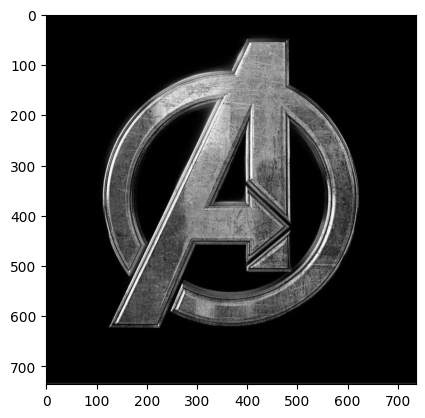

In [26]:

doomsday = cv.imread('doomsday.jpg')
doomsdayGray = cv.cvtColor(doomsday, cv.COLOR_BGR2GRAY)
plt.imshow(doomsdayGray, cmap='gray')

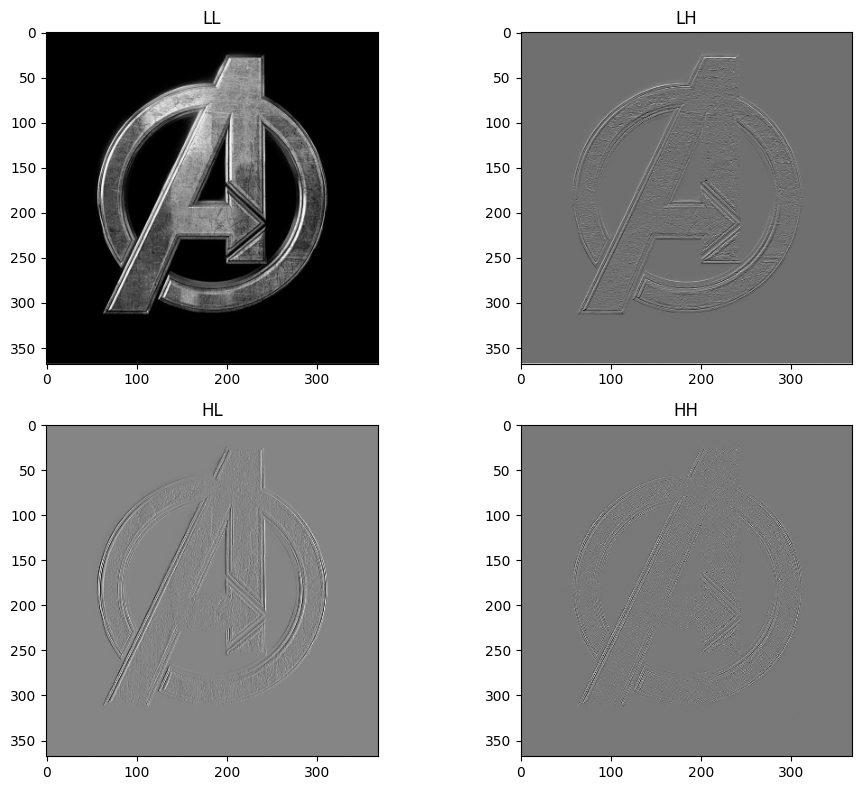

In [27]:
# LL (Approximation)
convLL_1 = filter_horizontal(doomsdayGray, LPF)
downLL_1 = subsampel_kolom(convLL_1)
convLL_2 = filter_vertikal(downLL_1, LPF)
LL = subsampel_baris(convLL_2)
LLNorm = normalisasi_citra(LL)

# LH (Horizontal Detail)
convLH_1 = filter_horizontal(doomsdayGray, LPF)
downLH_1 = subsampel_kolom(convLH_1)
convLH_2 = filter_vertikal(downLH_1, HPF)
LH = subsampel_baris(convLH_2)
LHNorm = normalisasi_citra(LH)

# HL (Vertical Detail)
convHL_1 = filter_horizontal(doomsdayGray, HPF)
downHL_1 = subsampel_kolom(convHL_1)
convHL_2 = filter_vertikal(downHL_1, LPF)
HL = subsampel_baris(convHL_2)
HLNorm = normalisasi_citra(HL)

# HH (Diagonal Detail)
convHH_1 = filter_horizontal(doomsdayGray, HPF)
downHH_1 = subsampel_kolom(convHH_1)
convHH_2 = filter_vertikal(downHH_1, HPF)
HH = subsampel_baris(convHH_2)
HHNorm = normalisasi_citra(HH).astype(np.uint8)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(LLNorm, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(LHNorm, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(HLNorm, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(HHNorm, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [28]:
def binerisasi_ambang(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] >= batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas

def ubah_ukuran(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

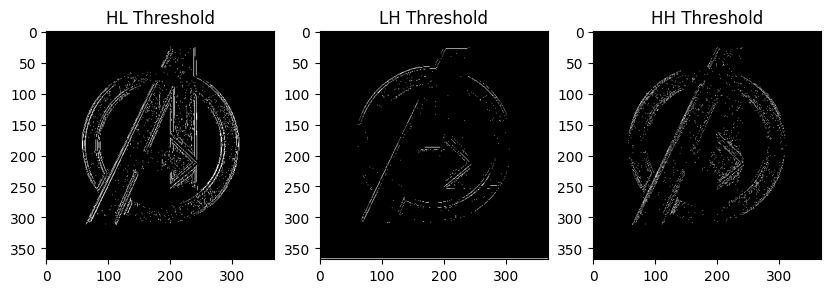

In [29]:
HL_resize = cv.resize(HL, (256, 256))
LH_resize = cv.resize(LH, (256, 256))
HH_resize = cv.resize(HH, (256, 256))

HL_tr = binerisasi_ambang(HLNorm, 150)
LH_tr = binerisasi_ambang(LHNorm, 150)
HH_tr = binerisasi_ambang(HHNorm, 150)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_tr, cmap='gray')
plt.title('HL Threshold')

plt.subplot(1,3,2)
plt.imshow(LH_tr, cmap='gray')
plt.title('LH Threshold')

plt.subplot(1,3,3)
plt.imshow(HH_tr, cmap='gray')
plt.title('HH Threshold')

plt.show()

In [30]:
def operasi_dilasi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def operasi_erosi(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil

def operasi_closing(image, kernel):
    return operasi_erosi(operasi_dilasi(image, kernel), kernel)


In [31]:
kernel5 = np.array ([[0, 0, 1, 0, 0],
                     [0, 1, 1, 1, 0],
                     [1, 1, 1, 1, 1],
                     [0, 1, 1, 1, 0],
                     [0, 0, 1, 0, 0]])

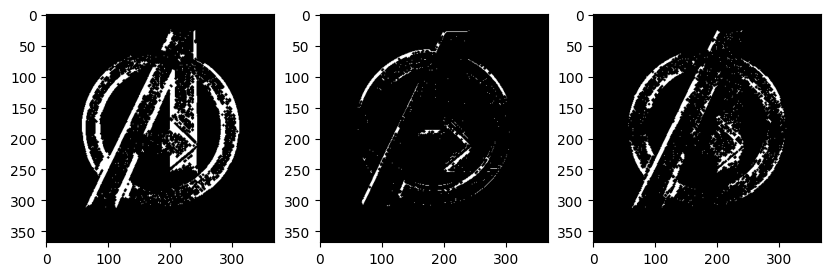

In [32]:
HL_cl = operasi_closing(HL_tr, kernel5)
LH_cl = operasi_closing(LH_tr, kernel5)
HH_cl = operasi_closing(HH_tr, kernel5)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(HL_cl, cmap='gray')

plt.subplot(1,3,2)
plt.imshow(LH_cl, cmap='gray')

plt.subplot(1,3,3)
plt.imshow(HH_cl, cmap='gray')

plt.show()

## Analisis No. 4 Morfologi Closing pada HL, LH, HH

Setelah thresholding (nilai = 150) dan operasi closing dengan kernel5 (bentuk diamond/plus), hasil ketiga subband menunjukkan karakteristik berbeda:

### HL (Vertical Detail / High-Low)

HL menangkap tepi vertikal dari citra — yaitu perubahan intensitas yang terjadi secara horizontal (gradien ke kiri-kanan).

Setelah thresholding, HL menampilkan garis-garis tepi vertikal dari logo Avengers, khususnya pada sisi kiri dan kanan huruf "A" dan lingkaran.

Setelah closing, piksel-piksel putih yang tadinya terputus (diskontinu) menjadi lebih terhubung dan menebal. Celah-celah kecil di antara tepi vertikal tertutup sehingga kontur tampak lebih solid dan kontinu. Detail kecil yang tidak relevan tetap tersaring.

Subband HL merupakan hasil kombinasi proses high-pass filtering pada arah horizontal dan low-pass filtering pada arah vertikal. Karena itu, komponen ini sangat sensitif terhadap perubahan intensitas yang terjadi dari kiri ke kanan. Pada logo Avengers, terdapat banyak elemen yang memiliki batas vertikal yang jelas, seperti sisi kiri dan kanan huruf "A", bagian batang huruf, serta sisi-sisi lingkaran yang mengelilingi logo. Akibatnya, energi koefisien pada subband HL relatif tinggi dibandingkan subband detail lainnya.

Ketika threshold 150 diterapkan, hanya koefisien dengan magnitudo besar yang dipertahankan. Koefisien tersebut umumnya berasal dari tepi objek yang kuat, sedangkan koefisien dengan nilai kecil yang biasanya mewakili noise, tekstur halus, atau variasi intensitas yang tidak signifikan akan dihilangkan. Proses ini menghasilkan citra biner yang menonjolkan tepi-tepi vertikal utama, tetapi sering kali menyebabkan garis menjadi terputus akibat hilangnya beberapa piksel yang nilainya berada sedikit di bawah ambang batas.

Operasi closing kemudian berperan untuk memperbaiki kondisi tersebut. Closing merupakan kombinasi antara dilasi yang diikuti erosi. Pada tahap dilasi, area putih diperluas sehingga celah kecil di antara segmen tepi dapat tertutup. Setelah itu, erosi mengembalikan bentuk objek mendekati ukuran semula tanpa menghilangkan koneksi yang telah terbentuk. Hasil akhirnya adalah garis vertikal yang lebih menyatu dan memiliki kontinuitas yang lebih baik.

Penggunaan kernel berbentuk diamond/plus ukuran 5 juga memberikan pengaruh penting. Bentuk kernel ini memperkuat hubungan piksel pada arah vertikal dan horizontal tanpa terlalu memperbesar area secara diagonal. Oleh karena itu, garis-garis vertikal yang menjadi karakter utama HL dapat dipertahankan sekaligus diperkuat. Efek ini terlihat pada kontur huruf "A" yang menjadi lebih utuh dan mudah dikenali.

Selain meningkatkan konektivitas, closing juga mengurangi jumlah komponen kecil yang terisolasi. Piksel-piksel tunggal atau fragmen pendek yang sebelumnya muncul akibat proses thresholding dapat bergabung dengan struktur utama atau hilang selama proses erosi. Dengan demikian, hasil HL setelah closing menjadi lebih bersih, lebih stabil, dan lebih representatif terhadap bentuk asli objek.

Secara visual, subband HL setelah closing biasanya menjadi salah satu subband yang paling informatif karena berhasil mempertahankan struktur dominan logo. Hal ini menunjukkan bahwa sebagian besar informasi bentuk pada logo Avengers tersimpan pada komponen tepi vertikal yang direpresentasikan oleh HL.

---

### LH (Horizontal Detail / Low-High)

LH menangkap tepi horizontal dari citra — perubahan intensitas secara vertikal (gradien atas-bawah).

Hasil thresholding LH memperlihatkan garis-garis horizontal yang dominan, terutama bagian atas dan bawah huruf "A" serta bagian atas-bawah lingkaran.

Setelah closing, tepi horizontal yang sebelumnya putus-putus menjadi lebih menyambung dan membentuk area yang lebih lebar. Bentuk logo menjadi lebih mudah dikenali dibanding sebelum closing.

Subband LH diperoleh dari proses low-pass filtering pada arah horizontal dan high-pass filtering pada arah vertikal. Karakteristik ini membuat LH lebih responsif terhadap perubahan intensitas yang terjadi dari atas ke bawah. Dengan kata lain, LH berfungsi untuk mengekstraksi informasi tepi horizontal yang terdapat pada citra.

Pada logo Avengers, komponen horizontal muncul pada bagian atas dan bawah huruf "A", perpotongan garis pada huruf, serta bagian atas dan bawah lingkaran. Walaupun jumlah tepi horizontal tidak sebanyak tepi vertikal, informasi yang tersimpan pada LH tetap penting karena membantu membentuk struktur geometris objek secara keseluruhan.

Setelah thresholding dilakukan, hanya tepi horizontal yang memiliki respons kuat yang akan dipertahankan. Akibatnya, beberapa bagian garis horizontal terlihat terfragmentasi atau terpisah menjadi beberapa segmen pendek. Fenomena ini muncul karena nilai koefisien di sepanjang tepi tidak selalu seragam. Ada bagian yang memiliki magnitudo tinggi dan bertahan setelah thresholding, sedangkan bagian lain yang sedikit lebih lemah akan hilang.

Ketika operasi closing diterapkan, segmen-segmen horizontal yang sebelumnya terputus mulai tersambung kembali. Dilasi memperluas area putih sehingga jarak antarsegmen yang kecil dapat dijembatani. Selanjutnya, erosi mempertahankan bentuk hasil penggabungan tersebut sehingga garis menjadi lebih kontinu.

Kernel diamond/plus ukuran 5 sangat efektif dalam proses ini karena mendukung penyambungan piksel pada arah utama (vertikal dan horizontal). Oleh sebab itu, garis-garis horizontal yang sebelumnya terdiri dari beberapa bagian kecil dapat berubah menjadi struktur yang lebih panjang dan lebih jelas.

Efek lain yang terlihat adalah bertambahnya ketebalan tepi horizontal. Walaupun ketebalan tambahan ini relatif kecil, dampaknya cukup signifikan terhadap keterbacaan bentuk. Area yang sebelumnya tampak tipis dan terputus menjadi lebih mudah diamati dan diinterpretasikan sebagai bagian dari objek utama.

Selain memperbaiki konektivitas, closing juga membantu mengurangi lubang kecil atau gap yang terdapat di dalam area hasil thresholding. Hal ini menghasilkan representasi yang lebih homogen dan stabil. Bagian atas dan bawah huruf "A" serta lengkungan lingkaran menjadi lebih jelas sehingga bentuk logo secara keseluruhan semakin mudah dikenali.

Dibandingkan sebelum closing, hasil LH setelah closing menunjukkan peningkatan kualitas visual yang cukup besar. Walaupun informasi horizontal bukan komponen dominan pada logo Avengers, keberadaannya sangat membantu dalam memperjelas struktur dan meningkatkan keutuhan bentuk objek.

---

### HH (Diagonal Detail / High-High)

HH menangkap tepi diagonal — perubahan intensitas ke arah sudut 45° dan 135°.

Hasil thresholding HH paling jarang/sparse dibanding HL dan LH, karena tepi diagonal pada citra ini lebih sedikit. Noise juga lebih banyak muncul di subband ini.

Setelah closing, piksel yang tersebar akibat noise diagonal bergabung membentuk blob/area kecil yang lebih padat, namun hasilnya tetap lebih tidak terstruktur dibanding HL dan LH karena sifat dasar diagonal yang lebih kompleks.

Subband HH merupakan hasil high-pass filtering pada arah horizontal dan vertikal secara bersamaan. Karena kedua arah mengalami penyaringan frekuensi tinggi, HH berisi informasi perubahan intensitas yang sangat cepat, terutama pada tepi diagonal, sudut tajam, tekstur halus, serta detail-detail kompleks lainnya.

Pada logo Avengers, informasi diagonal terutama berasal dari sisi miring huruf "A", perpotongan garis miring, dan beberapa bagian lengkungan yang membentuk sudut tertentu. Namun jumlah komponen diagonal dalam citra relatif lebih sedikit dibandingkan komponen vertikal dan horizontal. Oleh karena itu, energi yang tersimpan pada HH biasanya lebih rendah.

Setelah thresholding diterapkan, hanya sebagian kecil koefisien diagonal yang memiliki nilai cukup tinggi untuk dipertahankan. Akibatnya, citra HH terlihat lebih jarang (sparse), dengan banyak area hitam dan hanya beberapa titik atau fragmen putih yang tersebar. Pada tahap ini, noise juga sering tampak lebih dominan karena HH merupakan subband yang sangat sensitif terhadap variasi intensitas berfrekuensi tinggi.

Operasi closing berusaha menghubungkan piksel-piksel putih yang berdekatan. Ketika dilasi dilakukan, titik-titik putih yang tersebar akan membesar dan mulai saling bertemu. Setelah erosi, area yang telah terhubung tersebut tetap dipertahankan sehingga terbentuk kumpulan piksel yang lebih padat.

Berbeda dengan HL dan LH yang memiliki arah dominan yang jelas, HH merepresentasikan detail diagonal dari berbagai orientasi. Akibatnya, hasil penggabungan piksel pada HH tidak membentuk garis yang rapi, melainkan cenderung menghasilkan blob atau area kecil yang bentuknya tidak beraturan.

Fenomena ini menunjukkan bahwa closing pada HH lebih banyak meningkatkan kepadatan dan konektivitas lokal daripada membangun struktur geometris yang jelas. Walaupun beberapa fragmen diagonal berhasil digabungkan, bentuk keseluruhan objek masih sulit dikenali hanya dari subband HH saja.

Selain itu, sebagian noise yang berdekatan juga dapat ikut tergabung selama proses closing. Karena itulah hasil HH sering tampak lebih kasar dibandingkan HL dan LH. Namun demikian, keberadaan HH tetap penting karena menyimpan informasi mengenai sudut, kemiringan, dan detail-detail kompleks yang tidak sepenuhnya direpresentasikan oleh dua subband lainnya.

Secara keseluruhan, HH memberikan kontribusi terhadap detail halus dan karakteristik diagonal objek. Setelah closing, subband ini menjadi lebih padat dan lebih stabil, tetapi tetap mempertahankan sifatnya sebagai representasi detail kompleks yang tidak terstruktur sejelas HL maupun LH.

---

### Kesimpulan Keseluruhan

Secara umum, operasi **morphological closing** dengan kernel diamond/plus ukuran 5 berhasil memperbaiki hasil thresholding pada ketiga subband detail wavelet. Pada **HL**, closing paling efektif karena mampu memperkuat dan menyambungkan tepi vertikal yang merupakan komponen dominan logo Avengers. Pada **LH**, closing meningkatkan kontinuitas tepi horizontal sehingga bentuk objek menjadi lebih mudah dikenali. Sementara pada **HH**, closing meningkatkan kepadatan dan konektivitas piksel diagonal, meskipun hasilnya tetap lebih kompleks dan kurang teratur dibandingkan dua subband lainnya.

Perbedaan hasil pada ketiga subband menunjukkan bahwa setiap subband wavelet menyimpan informasi arah yang berbeda. HL lebih merepresentasikan struktur vertikal, LH merepresentasikan struktur horizontal, sedangkan HH merepresentasikan detail diagonal dan tekstur kompleks. Operasi closing berfungsi sebagai tahap penyempurnaan yang meningkatkan kontinuitas bentuk, mengurangi fragmentasi akibat thresholding, dan menghasilkan representasi objek yang lebih jelas untuk proses analisis citra selanjutnya.


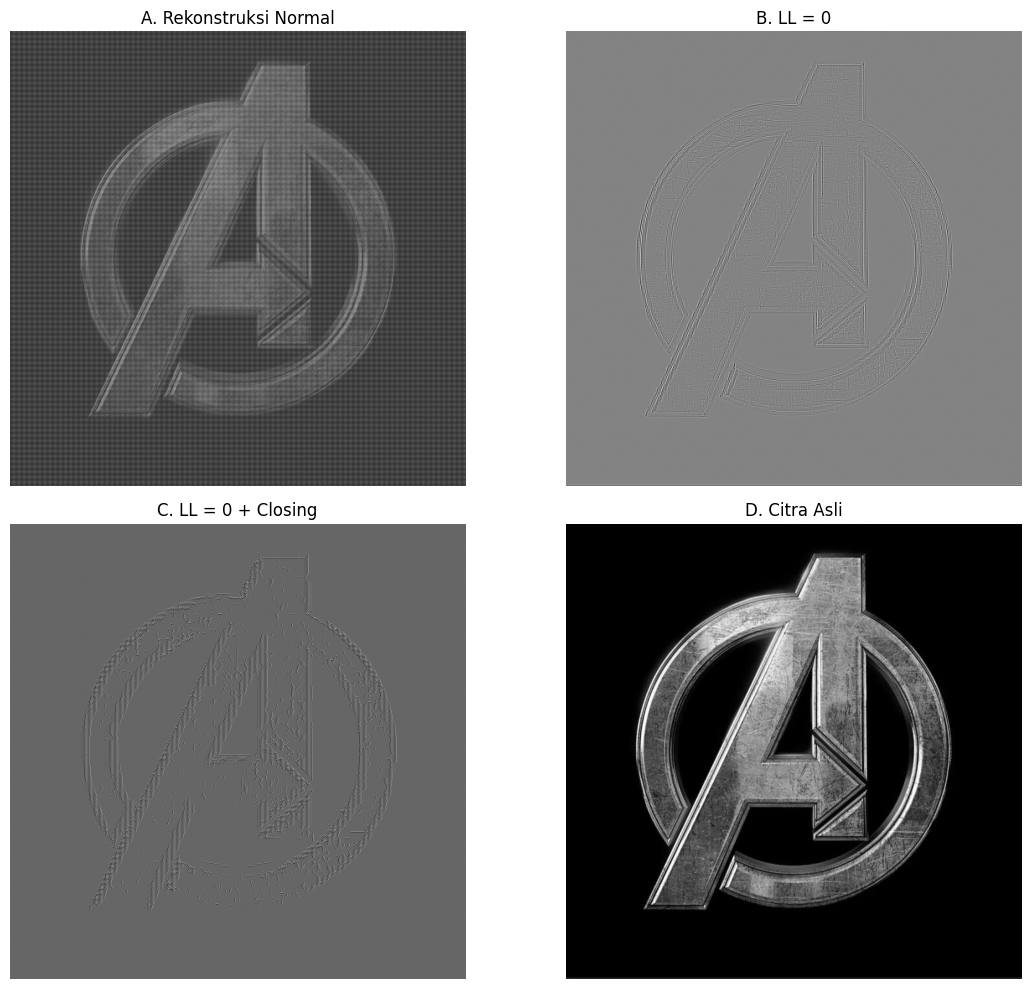

In [33]:
hasil_a = bangun_ulang_citra(LLNorm, HLNorm, LHNorm, HHNorm, LPF, HPF)
LL0 = np.zeros_like(LL)
hasil_b = bangun_ulang_citra(LL0, LH, HL, HH, LPF, HPF)
hasil_c = bangun_ulang_citra(LL0, LH_cl, HL_cl, HH_cl, LPF, HPF)

plt.figure(figsize=(12,10))

# a
plt.subplot(2,2,1)
plt.imshow(hasil_a, cmap='gray')
plt.title('A. Rekonstruksi Normal')
plt.axis('off')

# b
plt.subplot(2,2,2)
plt.imshow(hasil_b, cmap='gray')
plt.title('B. LL = 0')
plt.axis('off')

# c
plt.subplot(2,2,3)
plt.imshow(hasil_c, cmap='gray')
plt.title('C. LL = 0 + Closing')
plt.axis('off')

# d
plt.subplot(2,2,4)
plt.imshow(doomsdayGray, cmap='gray')
plt.title('D. Citra Asli')
plt.axis('off')

plt.tight_layout()
plt.show()

# Analisis No. 5 Rekonstruksi Wavelet

## a. Rekonstruksi Normal (LL + HL + LH + HH)

Hasil rekonstruksi dari keempat subband (LL, HL, LH, HH) menghasilkan citra yang mendekati citra asli grayscale.

LL membawa informasi frekuensi rendah (warna dasar, kecerahan, dan bentuk global), sedangkan HL, LH, HH membawa detail tepi dari berbagai arah.

Rekonstruksi ini membuktikan bahwa DWT (Discrete Wavelet Transform) bersifat reversible — citra dapat dikembalikan (hampir sempurna) ke bentuk aslinya dari subband-subbandnya.

Pada proses Discrete Wavelet Transform (DWT), citra asli diuraikan menjadi empat subband yang masing-masing menyimpan jenis informasi yang berbeda. LL berisi informasi aproksimasi atau informasi frekuensi rendah, sedangkan HL, LH, dan HH berisi informasi detail frekuensi tinggi. Ketika keempat subband tersebut digunakan kembali dalam proses Inverse Discrete Wavelet Transform (IDWT), seluruh informasi yang sebelumnya dipisahkan akan digabungkan kembali menjadi satu citra utuh.

Subband LL dapat dianggap sebagai kerangka utama citra karena memuat distribusi intensitas rata-rata, struktur objek secara keseluruhan, serta bentuk global citra. Sebagian besar energi citra biasanya terkonsentrasi pada subband ini. Oleh karena itu, walaupun resolusi LL lebih rendah dibanding citra asli, informasi visual yang terkandung di dalamnya masih sangat dominan.

Sementara itu, HL, LH, dan HH berfungsi sebagai komponen pelengkap yang mengembalikan detail-detail yang hilang apabila hanya LL yang digunakan. HL mengembalikan tepi vertikal, LH mengembalikan tepi horizontal, dan HH mengembalikan detail diagonal serta sudut-sudut objek. Ketiga subband detail ini berperan penting dalam menghasilkan citra yang tajam dan memiliki definisi bentuk yang jelas.

Pada hasil rekonstruksi normal, bentuk huruf "A", lingkaran logo Avengers, serta perbedaan intensitas antara objek dan latar dapat muncul kembali hampir identik dengan citra asli. Perbedaan yang mungkin muncul biasanya sangat kecil dan umumnya disebabkan oleh pembulatan numerik (rounding error) selama proses komputasi.

Keberhasilan rekonstruksi ini menunjukkan salah satu keunggulan utama transformasi wavelet, yaitu kemampuannya untuk memisahkan informasi berdasarkan frekuensi tanpa kehilangan informasi penting. Berbeda dengan beberapa metode transformasi lain yang dapat menyebabkan kehilangan data, DWT memungkinkan proses dekomposisi dan rekonstruksi dilakukan dengan tingkat akurasi yang sangat tinggi.

Secara matematis, kondisi ini menunjukkan bahwa informasi citra tidak hilang selama proses transformasi. Setiap subband menyimpan bagian tertentu dari informasi citra, dan ketika semuanya digabungkan kembali, citra asli dapat direkonstruksi dengan sangat baik. Oleh karena itu, wavelet banyak digunakan dalam kompresi citra, pengolahan citra medis, pengurangan noise, dan ekstraksi fitur.

---

## b. Rekonstruksi dengan LL = 0 (hanya HL + LH + HH)

Ketika LL diganti dengan matriks nol, informasi frekuensi rendah (warna dasar dan kecerahan global) dihilangkan.

Hasil rekonstruksi menampilkan hanya tepi-tepi citra — garis kontur logo Avengers tampak di atas latar abu-abu netral.

Latar belakang menjadi abu-abu (nilai tengah ~128) karena tidak ada informasi DC (rata-rata intensitas) yang dikontribusikan.

Ini membuktikan bahwa subband LL adalah pembawa informasi utama/global citra. Tanpanya, hanya "sketsa tepi" yang tersisa.

Percobaan ini bertujuan untuk mengamati kontribusi subband detail terhadap pembentukan citra. Dengan meniadakan LL, seluruh informasi frekuensi rendah dihilangkan dari proses rekonstruksi. Akibatnya, komponen yang tersisa hanyalah informasi perubahan intensitas yang direpresentasikan oleh HL, LH, dan HH.

Karena tidak ada lagi informasi kecerahan rata-rata, sistem rekonstruksi tidak memiliki referensi untuk menentukan tingkat intensitas dasar citra. Hasilnya, sebagian besar area citra berada di sekitar nilai tengah intensitas (gray level tengah), sehingga tampak abu-abu.

Pada kondisi ini, bagian yang masih terlihat hanyalah lokasi-lokasi yang memiliki perubahan intensitas signifikan, yaitu tepi objek. Garis-garis pembatas logo Avengers tetap muncul karena informasi tersebut tersimpan pada subband detail. Namun, area yang sebelumnya memiliki warna atau intensitas relatif seragam tidak lagi dapat direkonstruksi.

Fenomena ini menunjukkan bahwa detail saja tidak cukup untuk membentuk citra yang lengkap. Detail hanya menjelaskan di mana perubahan intensitas terjadi, tetapi tidak menjelaskan nilai intensitas sebenarnya pada setiap area citra. Informasi tersebut justru tersimpan pada LL.

Jika dianalogikan dengan gambar sketsa, HL, LH, dan HH berfungsi seperti garis-garis pensil yang menggambarkan kontur objek. Sebaliknya, LL berfungsi seperti arsiran dan pewarnaan yang memberikan bentuk, volume, dan informasi visual utama. Ketika arsiran dihilangkan, yang tersisa hanyalah garis kontur.

Selain itu, percobaan ini juga memperlihatkan bahwa sebagian besar energi citra memang terkonsentrasi pada frekuensi rendah. Walaupun HL, LH, dan HH masih mampu menunjukkan bentuk dasar objek, kualitas visualnya jauh berkurang dibandingkan rekonstruksi normal.

Hasil rekonstruksi ini sering dimanfaatkan dalam aplikasi ekstraksi fitur karena informasi tepi sering kali lebih penting dibandingkan informasi warna atau intensitas untuk tugas-tugas seperti deteksi objek, pengenalan pola, dan segmentasi citra.

---

## c. Rekonstruksi LL = 0 + HL/LH/HH yang sudah di-closing

Mirip dengan (b), tetapi subband detail yang digunakan sudah diproses closing (setelah thresholding) sehingga bersifat biner (0 atau 255).

Hasilnya: tepi yang tampak menjadi lebih tebal, lebih kontinu, namun lebih sedikit detail halus karena proses thresholding + closing menghilangkan variasi intensitas asli.

Bentuk logo masih dapat dikenali, tetapi tampak lebih kasar dan disederhanakan dibanding hasil (b).

Ini menunjukkan bahwa closing mengubah sifat frekuensi detail — informasi tepi halus hilang, terganti oleh area tepi yang lebih solid namun kurang presisi.

Pada tahap ini, subband HL, LH, dan HH tidak lagi berada dalam bentuk koefisien wavelet asli. Sebelum direkonstruksi, ketiga subband tersebut telah mengalami thresholding dan operasi morfologi closing. Akibatnya, sebagian besar informasi numerik asli yang terkandung dalam koefisien wavelet telah hilang.

Thresholding mengubah koefisien detail menjadi representasi yang jauh lebih sederhana. Koefisien dengan nilai kecil dihapus, sedangkan koefisien dengan nilai besar dipertahankan. Setelah itu, closing menghubungkan area-area yang berdekatan sehingga menghasilkan struktur tepi yang lebih tebal dan lebih solid.

Ketika subband yang telah dimodifikasi tersebut direkonstruksi, citra yang dihasilkan tidak lagi merepresentasikan detail asli secara akurat. Sebaliknya, citra lebih menyerupai hasil ekstraksi kontur atau hasil segmentasi tepi.

Garis-garis yang muncul terlihat lebih kuat dan lebih mudah diamati karena area putih yang berdekatan telah digabungkan selama proses closing. Namun, detail-detail kecil yang sebelumnya ada pada koefisien wavelet asli tidak dapat dipulihkan lagi. Informasi frekuensi tinggi yang halus telah hilang selama proses thresholding.

Hal ini menyebabkan beberapa perubahan visual yang jelas:

* Kontur menjadi lebih tebal.
* Garis terlihat lebih menyatu.
* Detail kecil berkurang.
* Sudut-sudut halus menjadi lebih kasar.
* Variasi tekstur hampir hilang sepenuhnya.

Walaupun bentuk umum logo Avengers masih dapat dikenali, tingkat kemiripannya terhadap citra asli lebih rendah dibandingkan hasil rekonstruksi pada bagian (b). Hal ini karena proses morfologi telah mengubah struktur detail yang awalnya bersifat kontinu menjadi representasi yang lebih sederhana.

Dari sudut pandang pengolahan citra, kondisi ini menunjukkan adanya trade-off antara penyederhanaan struktur dan pelestarian detail. Closing meningkatkan kontinuitas objek dan mengurangi noise, tetapi pada saat yang sama menghilangkan sebagian informasi asli yang terkandung pada frekuensi tinggi.

Percobaan ini juga memperlihatkan bahwa operasi morfologi tidak hanya memengaruhi bentuk objek pada domain spasial, tetapi juga secara tidak langsung memengaruhi karakteristik frekuensi ketika citra direkonstruksi kembali menggunakan IDWT.

---

## d. Subplot (2,2,4) — Citra Asli (Bonus)

Posisi subplot kanan bawah menampilkan citra grayscale asli sebagai referensi perbandingan visual terhadap ketiga hasil rekonstruksi di atas.

Keberadaan citra asli pada subplot terakhir sangat penting untuk evaluasi visual. Dengan menempatkan citra asli berdampingan dengan hasil rekonstruksi, perbedaan yang muncul akibat manipulasi subband wavelet dapat diamati secara langsung.

Citra asli berfungsi sebagai ground truth atau referensi utama yang menunjukkan bagaimana objek sebenarnya sebelum mengalami transformasi wavelet, thresholding, maupun operasi morfologi. Dari perbandingan ini dapat diamati bagian informasi mana yang dipertahankan dan bagian mana yang hilang selama setiap tahap pemrosesan.

Ketika dibandingkan dengan rekonstruksi normal, citra asli menunjukkan tingkat kemiripan yang sangat tinggi. Saat dibandingkan dengan rekonstruksi tanpa LL, terlihat jelas bahwa informasi global dan kecerahan citra hilang. Sedangkan ketika dibandingkan dengan rekonstruksi hasil closing, terlihat bahwa detail-detail halus telah disederhanakan menjadi kontur yang lebih kasar.

Keberadaan subplot referensi ini memudahkan proses analisis karena setiap perubahan visual dapat dikaitkan langsung dengan proses yang dilakukan pada subband wavelet tertentu.

---

# Kesimpulan Umum No. 5

Perbandingan keempat subplot menunjukkan peran kritis subband LL sebagai penyimpan informasi visual utama. Tanpa LL, rekonstruksi hanya menghasilkan informasi tepi. Proses closing pada subband detail menyederhanakan dan mempertebal tepi, namun mengorbankan ketajaman detail halus. DWT terbukti mampu memisahkan komponen frekuensi citra secara efektif dan bersifat reversible.

Secara keseluruhan, percobaan rekonstruksi wavelet ini memberikan gambaran yang sangat jelas mengenai fungsi masing-masing subband dalam representasi citra. LL berperan sebagai penyimpan informasi global yang mencakup bentuk utama, distribusi intensitas, dan karakter visual dominan. Sebaliknya, HL, LH, dan HH berfungsi sebagai penyimpan informasi detail yang memperkaya citra dengan tepi, sudut, dan tekstur.

Hasil rekonstruksi normal membuktikan bahwa kombinasi seluruh subband mampu menghasilkan citra yang sangat mendekati citra asli. Ketika LL dihilangkan, hanya informasi perubahan intensitas yang tersisa sehingga citra berubah menjadi representasi kontur atau sketsa tepi. Ketika subband detail terlebih dahulu dimodifikasi menggunakan thresholding dan closing, hasil rekonstruksi menjadi lebih sederhana, lebih tebal, dan lebih mudah dikenali sebagai objek, tetapi kehilangan banyak detail halus yang sebelumnya ada.

Analisis ini menunjukkan bahwa DWT bukan hanya alat untuk memecah citra ke dalam komponen frekuensi yang berbeda, tetapi juga sarana yang sangat efektif untuk memahami bagaimana setiap komponen frekuensi berkontribusi terhadap pembentukan informasi visual. Oleh karena itu, transformasi wavelet menjadi salah satu metode yang sangat penting dalam berbagai aplikasi pengolahan citra modern seperti kompresi citra, penghilangan noise (*denoising*), segmentasi objek, ekstraksi fitur, deteksi tepi, pengenalan pola, hingga analisis citra medis dan citra satelit.
